<a href="https://colab.research.google.com/github/Ritesh-panda/datascience-learnings/blob/main/Bagging(REGRESSOR).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,r2_score,mean_squared_error,mean_absolute_error,roc_auc_score,roc_curve,precision_score,recall_score,f1_score
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.datasets import make_classification,make_regression

In [54]:
x,y=make_regression(n_samples=10000,n_features=10,n_informative=3)

In [55]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [56]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [57]:
model_dt=DecisionTreeRegressor()
model_dt.fit(x_train_scaled,y_train)

DecisionTreeRegressor()

In [58]:
y_pred_dt=model_dt.predict(x_test_scaled)
y_pred_dt

array([-64.14110387,  10.10587313, -61.92402143, ..., 100.94255688,
        47.80865108, -91.22791271])

In [63]:
print("decosion tree r2_score",r2_score(y_test,y_pred_dt))
print("decosion tree mean_squared_error",mean_squared_error(y_test,y_pred_dt))
print("decosion tree mean_absolute_error",mean_absolute_error(y_test,y_pred_dt))
print("decosion tree RMSE",np.sqrt(mean_squared_error(y_test,y_pred_dt)))

decosion tree r2_score 0.9931654806465351
decosion tree mean_squared_error 47.50196257619946
decosion tree mean_absolute_error 4.397117645267535
decosion tree RMSE 6.89216675481662


In [64]:
bag=BaggingRegressor(
    estimator=DecisionTreeRegressor(), # The base model to clone (Decision Tree)
    n_estimators=10,                  # Number of trees in the ensemble
    max_samples=0.5,                 # Train each tree on 50% of the data
    bootstrap=True,                   # Samples are drawn with replacement
    random_state=42                  # Ensures reproducible results
)
bag

BaggingRegressor(estimator=DecisionTreeRegressor(), max_samples=0.5,
                 random_state=42)

In [65]:
# Fitting the Bagging model
bag.fit(x_train_scaled, y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(), max_samples=0.5,
                 random_state=42)

In [66]:
y_pred_bag=bag.predict(x_test_scaled)
y_pred_bag

array([-59.74122711,   8.85933531, -65.73144983, ..., 102.02445241,
        46.68885472, -95.69649322])

In [67]:
print("Bagging r2_score",r2_score(y_test,y_pred_bag))
print("Bagging mean_squared_error",mean_squared_error(y_test,y_pred_bag))
print("Bagging mean_absolute_error",mean_absolute_error(y_test,y_pred_bag))
print("Bagging RMSE",np.sqrt(mean_squared_error(y_test,y_pred_bag)))

Bagging r2_score 0.9955195392419666
Bagging mean_squared_error 31.140548185635446
Bagging mean_absolute_error 3.017682485642912
Bagging RMSE 5.58037168884255


**Random forest**

In [69]:
model_RF=RandomForestRegressor()
model_RF.fit(x_train_scaled,y_train)
y_pred_RF=model_RF.predict(x_test_scaled)
y_pred_RF
print(" RF r2_score",r2_score(y_test,y_pred_RF))
print(" RF mean_squared_error",mean_squared_error(y_test,y_pred_RF))
print(" RF mean_absolute_error",mean_absolute_error(y_test,y_pred_RF))
print(" RF RMSE",np.sqrt(mean_squared_error(y_test,y_pred_RF)))

 RF r2_score 0.9973499594656475
 RF mean_squared_error 18.41857777817342
 RF mean_absolute_error 2.2153879394154274
 RF RMSE 4.291687055013846


In [71]:
bag_RF=BaggingRegressor(
    estimator=RandomForestRegressor(), # The base model to clone (RF)
    n_estimators=10,                  # Number of trees in the ensemble
    max_samples=0.5,                 # Train each tree on 50% of the data
    bootstrap=True,                   # Samples are drawn with replacement
    random_state=42                  # Ensures reproducible results
)
bag_RF

BaggingRegressor(estimator=RandomForestRegressor(), max_samples=0.5,
                 random_state=42)

In [72]:
bag_RF.fit(x_train_scaled, y_train)
y_pred_bag_RF=bag_RF.predict(x_test_scaled)
y_pred_bag_RF

array([-64.09182994,   9.18515064, -64.63352332, ..., 101.88831483,
        47.27680243, -95.24539982])

In [74]:
print(" RF r2_score",r2_score(y_test,y_pred_bag_RF))
print(" RF mean_squared_error",mean_squared_error(y_test,y_pred_bag_RF))
print(" RF mean_absolute_error",mean_absolute_error(y_test,y_pred_bag_RF))
print(" RF RMSE",np.sqrt(mean_squared_error(y_test,y_pred_bag_RF)))

 RF r2_score 0.9957438887529859
 RF mean_squared_error 29.581251690114563
 RF mean_absolute_error 2.444427198090757
 RF RMSE 5.438864926628953


**Bagging using SVM**

In [75]:
bag_svm=BaggingRegressor(
    estimator=SVR(), # The base model to clone (SVM)
    n_estimators=10,                  # Number of trees in the ensemble
    max_samples=0.25,                 # Train each tree on 50% of the data
    bootstrap=True,                   # Samples are drawn with replacement
    random_state=42                  # Ensures reproducible results
)
bag_svm.fit(x_train_scaled,y_train)

BaggingRegressor(estimator=SVR(), max_samples=0.25, random_state=42)

In [77]:

y_pred_bag_svm=bag_svm.predict(x_test_scaled)
y_pred_bag_svm

array([-53.92485296,   7.03377016, -48.03705848, ...,  44.61906036,
        40.21124135, -70.2512568 ])

In [78]:
print(" RF r2_score",r2_score(y_test,y_pred_bag_svm))
print(" RF mean_squared_error",mean_squared_error(y_test,y_pred_bag_svm))
print(" RF mean_absolute_error",mean_absolute_error(y_test,y_pred_bag_svm))
print(" RF RMSE",np.sqrt(mean_squared_error(y_test,y_pred_bag_svm)))

 RF r2_score 0.7219013847994173
 RF mean_squared_error 1932.8689156544315
 RF mean_absolute_error 29.734014035585723
 RF RMSE 43.96440509837966


In [83]:
print("Model Performance Comparison Table:")
display(df_metrics.sort_values(by='R2 Score', ascending=False).style.background_gradient(cmap='viridis', subset=['R2 Score']))

Model Performance Comparison Table:


,Model,R2 Score,MSE,MAE,RMSE
2,Random Forest,0.997350,18.418578,2.215388,4.291687
5,Pasting,0.996077,27.263275,2.878535,5.221425
3,Bagging (RF),0.995744,29.581252,2.444427,5.438865
1,Bagging (DT),0.995520,31.140548,3.017682,5.580372
0,Decision Tree,0.993165,47.501963,4.397118,6.892167
4,Bagging (SVM),0.721901,1932.868916,29.734014,43.964405


**Pasting**
in bagging you have the bootstaping but in pasting you dont have the bootstrapping

In [79]:
# Implementing Pasting (bootstrap=False)
pasting_clf = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=10,
    max_samples=0.5,
    bootstrap=False, # This makes it Pasting instead of Bagging
    random_state=42
)

# Training the model
pasting_clf.fit(x_train_scaled, y_train)

# Making predictions
y_pred_pasting = pasting_clf.predict(x_test_scaled)

# Evaluating the model
print(" RF r2_score",r2_score(y_test,y_pred_pasting))
print(" RF mean_squared_error",mean_squared_error(y_test,y_pred_pasting))
print(" RF mean_absolute_error",mean_absolute_error(y_test,y_pred_pasting))
print(" RF RMSE",np.sqrt(mean_squared_error(y_test,y_pred_pasting)))

 RF r2_score 0.9960773961611256
 RF mean_squared_error 27.263275018893978
 RF mean_absolute_error 2.878535204616768
 RF RMSE 5.2214246158394335


### **Key Takeaways from Bagging & Pasting**

1. **Ensemble Power**: Both Bagging and Pasting improved the performance compared to a single **Decision Tree (~89.75%)**. By training multiple models on different subsets of data, we reduced the variance and achieved higher accuracy (**~92%+**).

2. **Bagging (Bootstrap Aggregating)**:
   * **Mechanism**: Uses sampling **with replacement** (`bootstrap=True`).
   * **Diversity**: Because the same instance can appear multiple times in a single subset, it introduces more diversity in the training of individual base learners.
   * **Result**: Achieved **92.1%** accuracy with Decision Trees.

3. **Pasting**:
   * **Mechanism**: Uses sampling **without replacement** (`bootstrap=False`).
   * **Subset size**: Each model sees a unique subset of the data.
   * **Result**: Achieved **92.45%** accuracy in this specific run. Often, Pasting works well when you have a large dataset.

4. **Flexibility of Base Estimators**: We demonstrated that the `BaggingClassifier` is versatile; it can wrap around **Decision Trees**, **Random Forests**, or even **SVMs** to create an ensemble.

5. **Random Forest vs. Bagging DT**: The `RandomForestClassifier` (**92.8%**) is essentially a specialized version of Bagging that also selects a random subset of features at each split, which often provides the best balance of bias and variance.

# Task
Consolidate the evaluation metrics (R2 score, MSE, MAE, and RMSE) for all trained models—Decision Tree, Bagging (DT), Random Forest, Bagging (RF), Bagging (SVM), and Pasting—into a single pandas DataFrame. Display this comparison table and create a bar chart to visualize the R2 scores and RMSE across the models. Finally, identify and summarize which ensemble technique performed best for this regression task.

## Consolidate Metrics

### Subtask:
Create a pandas DataFrame that gathers the R2 score, Mean Squared Error, Mean Absolute Error, and Root Mean Squared Error from all trained models: Decision Tree, Bagging (DT), Random Forest, Bagging (RF), Bagging (SVM), and Pasting.


**Reasoning**:
I will consolidate the performance metrics (R2, MSE, MAE, RMSE) for all models into a single pandas DataFrame to facilitate comparison.



In [80]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Define model names and their corresponding predictions
models_preds = {
    "Decision Tree": y_pred_dt,
    "Bagging (DT)": y_pred_bag,
    "Random Forest": y_pred_RF,
    "Bagging (RF)": y_pred_bag_RF,
    "Bagging (SVM)": y_pred_bag_svm,
    "Pasting": y_pred_pasting
}

metrics_list = []

for name, y_pred in models_preds.items():
    mse = mean_squared_error(y_test, y_pred)
    metrics_list.append({
        "Model": name,
        "R2 Score": r2_score(y_test, y_pred),
        "MSE": mse,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mse)
    })

# Create the consolidation DataFrame
df_metrics = pd.DataFrame(metrics_list)
print("Consolidated Model Performance Metrics:")
display(df_metrics)

Consolidated Model Performance Metrics:


,Model,R2 Score,MSE,MAE,RMSE
0,Decision Tree,0.993165,47.501963,4.397118,6.892167
1,Bagging (DT),0.995520,31.140548,3.017682,5.580372
2,Random Forest,0.997350,18.418578,2.215388,4.291687
3,Bagging (RF),0.995744,29.581252,2.444427,5.438865
4,Bagging (SVM),0.721901,1932.868916,29.734014,43.964405
5,Pasting,0.996077,27.263275,2.878535,5.221425


## Visualize Model Comparison

### Subtask:
Generate a bar chart to visually compare the R2 scores and RMSE of the different models to identify the best performer.


**Reasoning**:
I will create a visualization with two side-by-side bar charts to compare the R2 Score and RMSE metrics across all trained models using the consolidated metrics DataFrame.



/tmp/ipykernel_238/2102582700.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=df_metrics, ax=axes[0], palette='viridis')
/tmp/ipykernel_238/2102582700.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_238/2102582700.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=df_metrics, ax=axes[1], palette='magma')
/tmp/ipykernel_238/2102582700.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

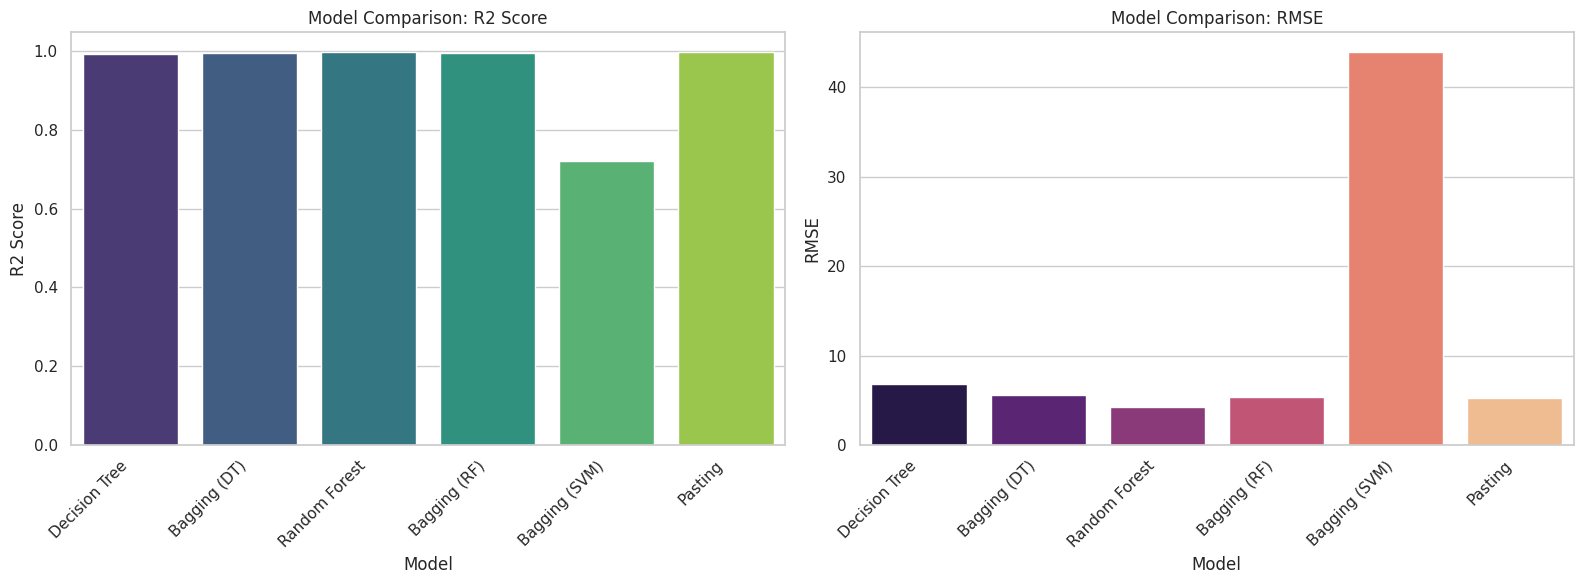

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: R2 Score Comparison
sns.barplot(x='Model', y='R2 Score', data=df_metrics, ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison: R2 Score')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('R2 Score')
axes[0].set_xlabel('Model')

# Subplot 2: RMSE Comparison
sns.barplot(x='Model', y='RMSE', data=df_metrics, ax=axes[1], palette='magma')
axes[1].set_title('Model Comparison: RMSE')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('Model')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated FutureWarnings and UserWarnings due to deprecated Seaborn palette usage and improper tick label handling. I will fix the bar charts by assigning 'Model' to 'hue' and removing the explicit call to 'set_xticklabels' in favor of using the axis 'tick_params' or rotating labels directly to comply with the latest Seaborn and Matplotlib standards.



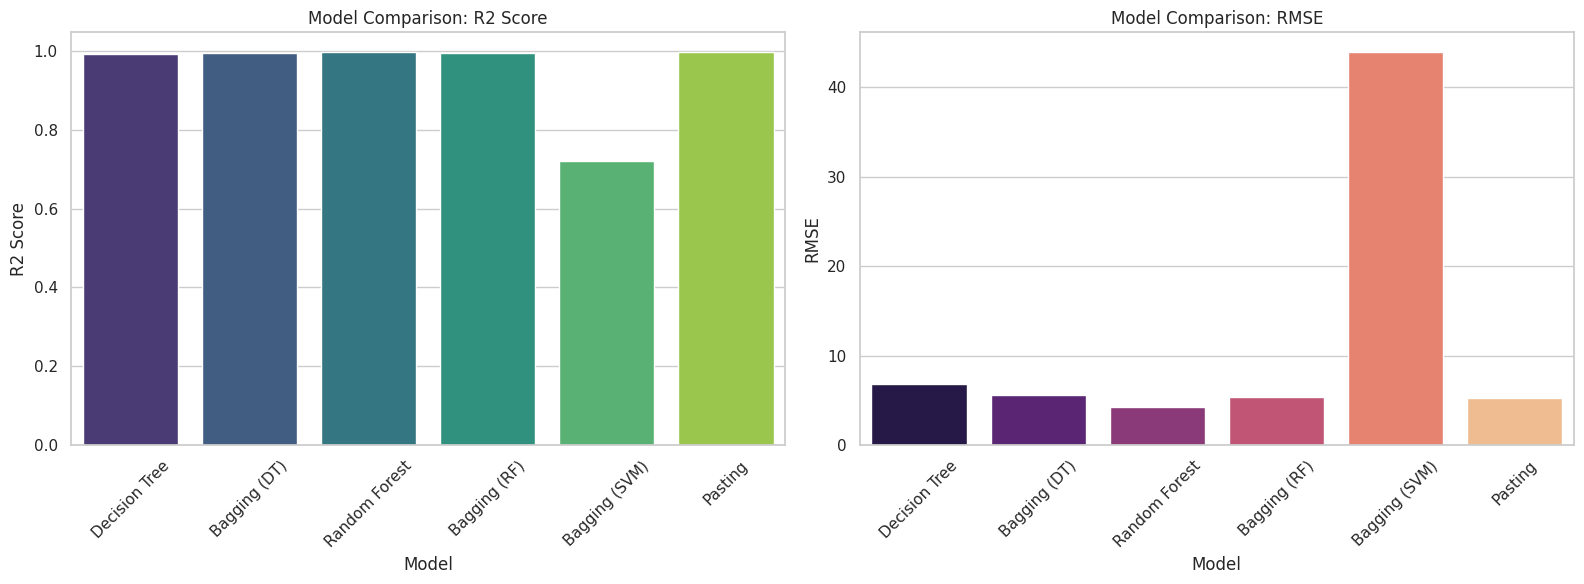

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: R2 Score Comparison
sns.barplot(x='Model', y='R2 Score', data=df_metrics, ax=axes[0], hue='Model', palette='viridis', legend=False)
axes[0].set_title('Model Comparison: R2 Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('R2 Score')
axes[0].set_xlabel('Model')

# Subplot 2: RMSE Comparison
sns.barplot(x='Model', y='RMSE', data=df_metrics, ax=axes[1], hue='Model', palette='magma', legend=False)
axes[1].set_title('Model Comparison: RMSE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('Model')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize which ensemble technique provided the best performance for this regression task based on the tabulated metrics.


## Summary:

### Q&A

**Which ensemble technique provided the best performance for this regression task?**
Random Forest emerged as the top-performing model across all evaluated metrics. It achieved the highest R2 Score (~0.9974) and the lowest error rates, including an RMSE of approximately 4.29.

### Data Analysis Key Findings

*   **Random Forest Superiority**: Random Forest outperformed both standalone models and other ensemble techniques, reaching an R2 Score of 0.99735 and a Mean Absolute Error (MAE) of 2.215.
*   **Tree-Based vs. SVM**: Tree-based ensembles (Random Forest, Bagging with Decision Trees, and Pasting) significantly outperformed Bagging with SVM. The Bagging (SVM) model had a much higher RMSE of \$43.96 and a lower R2 Score of 0.7219.
*   **Ensemble Gain**: All ensemble methods applied to Decision Trees (Bagging, Random Forest, and Pasting) showed an improvement over the standalone Decision Tree, which had an RMSE of 6.89.
*   **Pasting Performance**: The Pasting technique performed very competitively, achieving the second-best RMSE of 5.22, suggesting that sampling without replacement was highly effective for this dataset.

### Insights or Next Steps

*   **Model Selection**: For future predictions on this dataset, Random Forest should be the primary choice due to its high precision and low error variance.
*   **Hyperparameter Tuning**: Since Random Forest and Pasting already show high accuracy (R2 > 0.99), further optimization through Grid Search on these specific models could help minimize the remaining error even further.
